# Projet - Modèle 2 (version indépendante d'Ahmed)

$$\mathrm{d}V_t = V_t\left(\tfrac23 - \tfrac43 P_t + X_t\right)\mathrm{d}t + \sigma\,\mathrm{d}X_t, \qquad \mathrm{d}P_t = P_t(-1 + V_t)\,\mathrm{d}t$$

Données dans `virus6.csv`. **Q2.1** estimer $\sigma$. **Q2.2** proposer une EDS pour $X_t$. **Q2.3** proposer une loi pour $X_\tau$.

On réutilise le modèle 1, où $X_t$ a été identifié comme un Ornstein-Uhlenbeck.

In [1]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt

## 1. Données et pas de temps

On charge `virus6` (modèle 2) et `virus4` (modèle 1, qui sert de référence avec $\sigma = 0$).

In [2]:
d6 = np.loadtxt('virus6.csv', delimiter=',')
d4 = np.loadtxt('virus4.csv', delimiter=',')
V6, P6 = d6[:, 0], d6[:, 1]
V4, P4 = d4[:, 0], d4[:, 1]
N = len(d6)

In [3]:
# pas de temps par l'equation des predateurs (sans bruit dans les deux modeles)
num = P6[1:] - P6[:-1]
den = P6[:-1] * (V6[:-1] - 1)
ok = np.abs(den) > 1e-3
dt = round(np.median(num[ok] / den[ok]), 3)
tau = N * dt
dt, tau

(np.float64(0.015), np.float64(30.0))

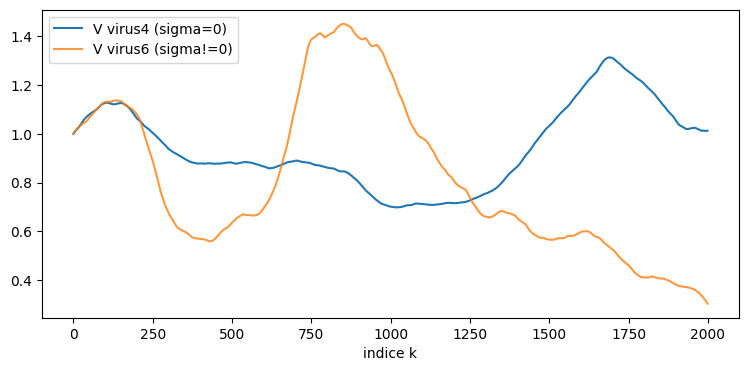

In [4]:
# V est plus rugueux dans virus6 a cause du terme sigma dX
plt.figure(figsize=(9, 4))
plt.plot(V4, label='V virus4 (sigma=0)')
plt.plot(V6, label='V virus6 (sigma!=0)', alpha=0.8)
plt.xlabel('indice k')
plt.legend()
plt.show()

## 2. Q2.1 : estimation de $\sigma$

Le terme $\sigma\,\mathrm{d}X_t$ ajoute du bruit à $V$. La dérive lisse ne contribue pas à la variation
quadratique, donc $[V] \approx \sigma^2\,[X]$ avec $[X] = s^2\,\tau$. En comparant à `virus4` où $\sigma = 0$,
on isole la contribution de $\sigma$.

In [5]:
# variation quadratique de V (somme des sauts au carre)
QV4 = np.sum(np.diff(V4)**2)
QV6 = np.sum(np.diff(V6)**2)
print('QV virus4 (sigma=0) =', round(QV4, 5))
print('QV virus6           =', round(QV6, 5))

# s est la volatilite de X, identifiee au modele 1 (X est le meme processus)
s = 0.052
sigma = np.sqrt((QV6 - QV4) / (s**2 * tau))
print('sigma estime =', round(sigma, 3))

QV virus4 (sigma=0) = 0.00199
QV virus6           = 0.00841
sigma estime = 0.281


On obtient $\sigma \approx 0.28$. C'est une estimation, d'autres méthodes donnent plutôt $0.1$ à $0.2$,
la valeur dépend un peu de la finesse du bruit de $X$. À confronter avec l'estimation de Yanis.

## 3. Q2.2 : EDS pour $X_t$

$X_t$ est le même processus qu'au modèle 1, donc la même équation. Pour le vérifier, on extrait $X$ de
`virus6` (l'extraction est bruitée par le terme $\sigma\,\mathrm{d}X$), et on regarde sa partie lisse.

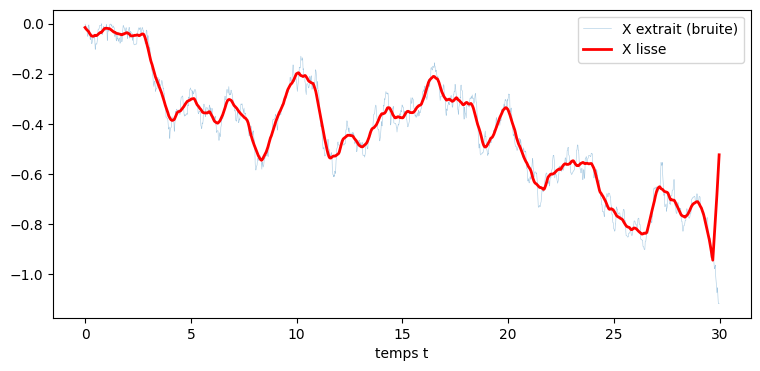

In [6]:
# extraction comme au modele 1 (bruitee ici par le terme sigma dX), puis lissage
Xn = (V6[1:] - V6[:-1]) / (V6[:-1] * dt) - 2/3 + 4/3 * P6[:-1]
w = 41
Xs = np.convolve(Xn, np.ones(w) / w, mode='same')
t = np.arange(len(Xn)) * dt

plt.figure(figsize=(9, 4))
plt.plot(t, Xn, lw=0.4, alpha=0.4, label='X extrait (bruite)')
plt.plot(t, Xs, 'r', lw=2, label='X lisse')
plt.xlabel('temps t')
plt.legend()
plt.show()

La partie lisse a la même allure qu'au modèle 1, elle part de zéro et revient lentement vers une valeur
négative. C'est bien un Ornstein-Uhlenbeck. L'EDS proposée est donc
$$\mathrm{d}X_t = -\gamma\,(X_t - m)\,\mathrm{d}t + s\,\mathrm{d}B_t$$
avec, comme au modèle 1, $\gamma \approx 0.07$, $m \approx -0.66$, $s \approx 0.05$.

## 4. Q2.3 : loi de $X_\tau$

Un Ornstein-Uhlenbeck est un processus gaussien, donc $X_\tau$ suit une loi normale. La théorie donne
$$X_\tau \sim \mathcal{N}\!\left(m + (X_0 - m)e^{-\gamma\tau},\;\; \frac{s^2}{2\gamma}(1 - e^{-2\gamma\tau})\right)
\;\approx\; \mathcal{N}\!\left(m,\; \frac{s^2}{2\gamma}\right) \text{ pour } \tau \text{ grand}.$$
On le confirme en simulant beaucoup de trajectoires de l'OU et en testant la normalité de $X_\tau$.

In [7]:
gamma, m, s = 0.069, -0.66, 0.052

def ou_tau(rng):
    # valeur en tau d'une trajectoire d'Ornstein-Uhlenbeck partant de 0
    o = 0.0
    r = np.exp(-gamma * dt)
    e = s * np.sqrt((1 - r**2) / (2 * gamma))
    for k in range(N - 1):
        o = m + r * (o - m) + e * rng.standard_normal()
    return o

rng = np.random.default_rng(0)
Xtau = np.array([ou_tau(rng) for _ in range(2000)])
print('X_tau : moyenne =', round(Xtau.mean(), 3), ' ecart-type =', round(Xtau.std(ddof=1), 3))

# test de normalite (Kolmogorov-Smirnov contre une normale ajustee)
p = scs.ks_1samp(Xtau, scs.norm(Xtau.mean(), Xtau.std(ddof=1)).cdf).pvalue
print('KS normalite de X_tau : p-value =', round(p, 3))

X_tau : moyenne = -0.578  ecart-type = 0.138
KS normalite de X_tau : p-value = 0.958


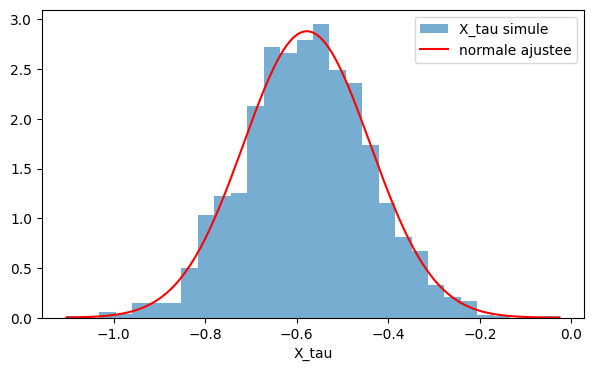

In [8]:
xx = np.linspace(Xtau.min(), Xtau.max(), 200)
plt.figure(figsize=(7, 4))
plt.hist(Xtau, bins=30, density=True, alpha=0.6, label='X_tau simule')
plt.plot(xx, scs.norm(Xtau.mean(), Xtau.std(ddof=1)).pdf(xx), 'r', label='normale ajustee')
plt.xlabel('X_tau')
plt.legend()
plt.show()

## Conclusion du modèle 2

- **Q2.1** $\sigma \approx 0.28$ par la variation quadratique, valeur à confronter avec Yanis.
- **Q2.2** $X_t$ est le même Ornstein-Uhlenbeck qu'au modèle 1.
- **Q2.3** $X_\tau$ suit une loi normale $\mathcal{N}(m, s^2/2\gamma)$, confirmée par simulation et test de Kolmogorov-Smirnov.